In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from math import log
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

In [12]:
statistics_file = os.path.join("/", "home", "data", "robustness", "robustness_tests_statistics.csv")
statistics = pd.read_csv(statistics_file)

In [21]:
statistics["absR"] = statistics["r"].abs()
statistics.groupby(["irrigation_frequency", "soil_texture", "irrigation_strategy"]).agg(
    mean_absR=("absR", "sum")
)

mean_absR
irrigation_frequency soil_texture irrigation_strategy           
1                    cloamy       ET0                  67.174755
                                  SMARTER_PIDenhanced  17.157174
                     sandy        ET0                  65.474391
                                  SMARTER_PIDenhanced  23.174782
                     silty        ET0                  93.708505
                                  SMARTER_PIDenhanced  18.754081
2                    cloamy       ET0                  63.179242
                                  SMARTER_PIDenhanced  18.985957
                     sandy        ET0                  61.404547
                                  SMARTER_PIDenhanced  26.355225
                     silty        ET0                  42.434970
                                  SMARTER_PIDenhanced  22.957646
3                    cloamy       ET0                  58.567720
                                  SMARTER_PIDenhanced  21.399458
                     sandy        ET0                  58.902959
                                  SMARTER_PIDenhanced  28.213603
                     silty        ET0                  38.040282
                                  SMARTER_PIDenhanced  25.984698
5                    cloamy       ET0                  81.209001
                                  SMARTER_PIDenhanced  26.257169
                     sandy        ET0                  76.471563
                                  SMARTER_PIDenhanced  35.423791
                     silty        ET0                  58.944167
                                  SMARTER_PIDenhanced  31.653822
7                    cloamy       ET0                  42.219302
                                  SMARTER_PIDenhanced  32.012089
                     sandy        ET0                  56.301327
                                  SMARTER_PIDenhanced  42.528142
                     silty        ET0                  41.568387
                                  SMARTER_PIDenhanced  39.683581

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


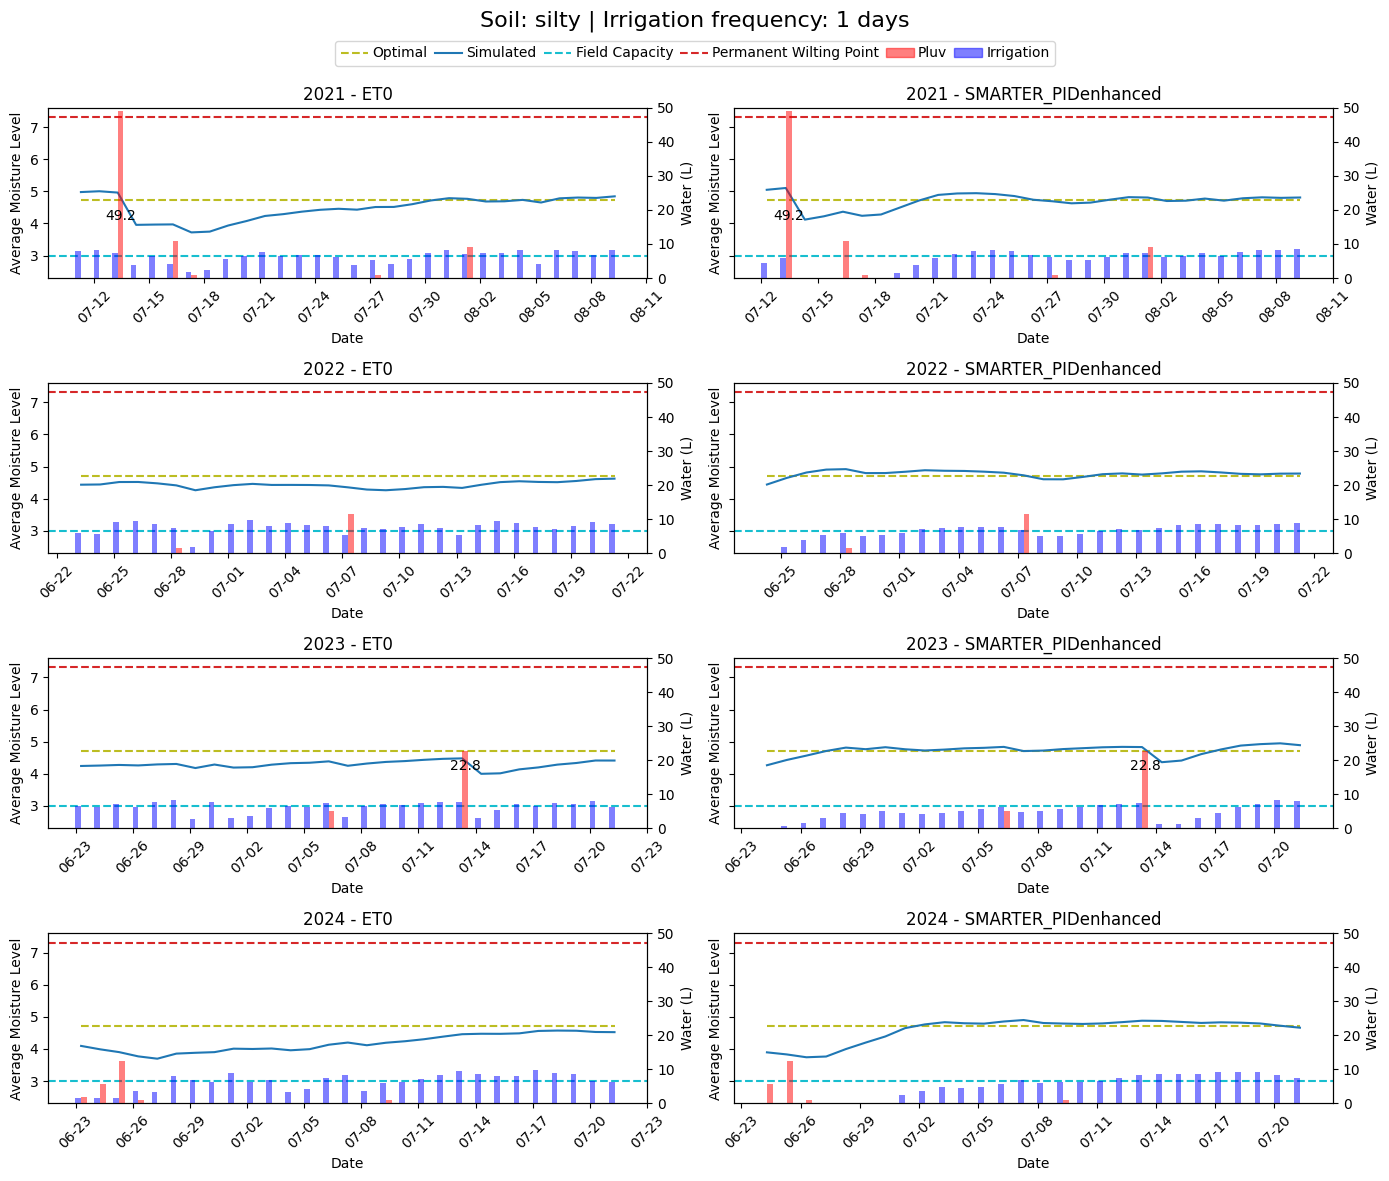

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


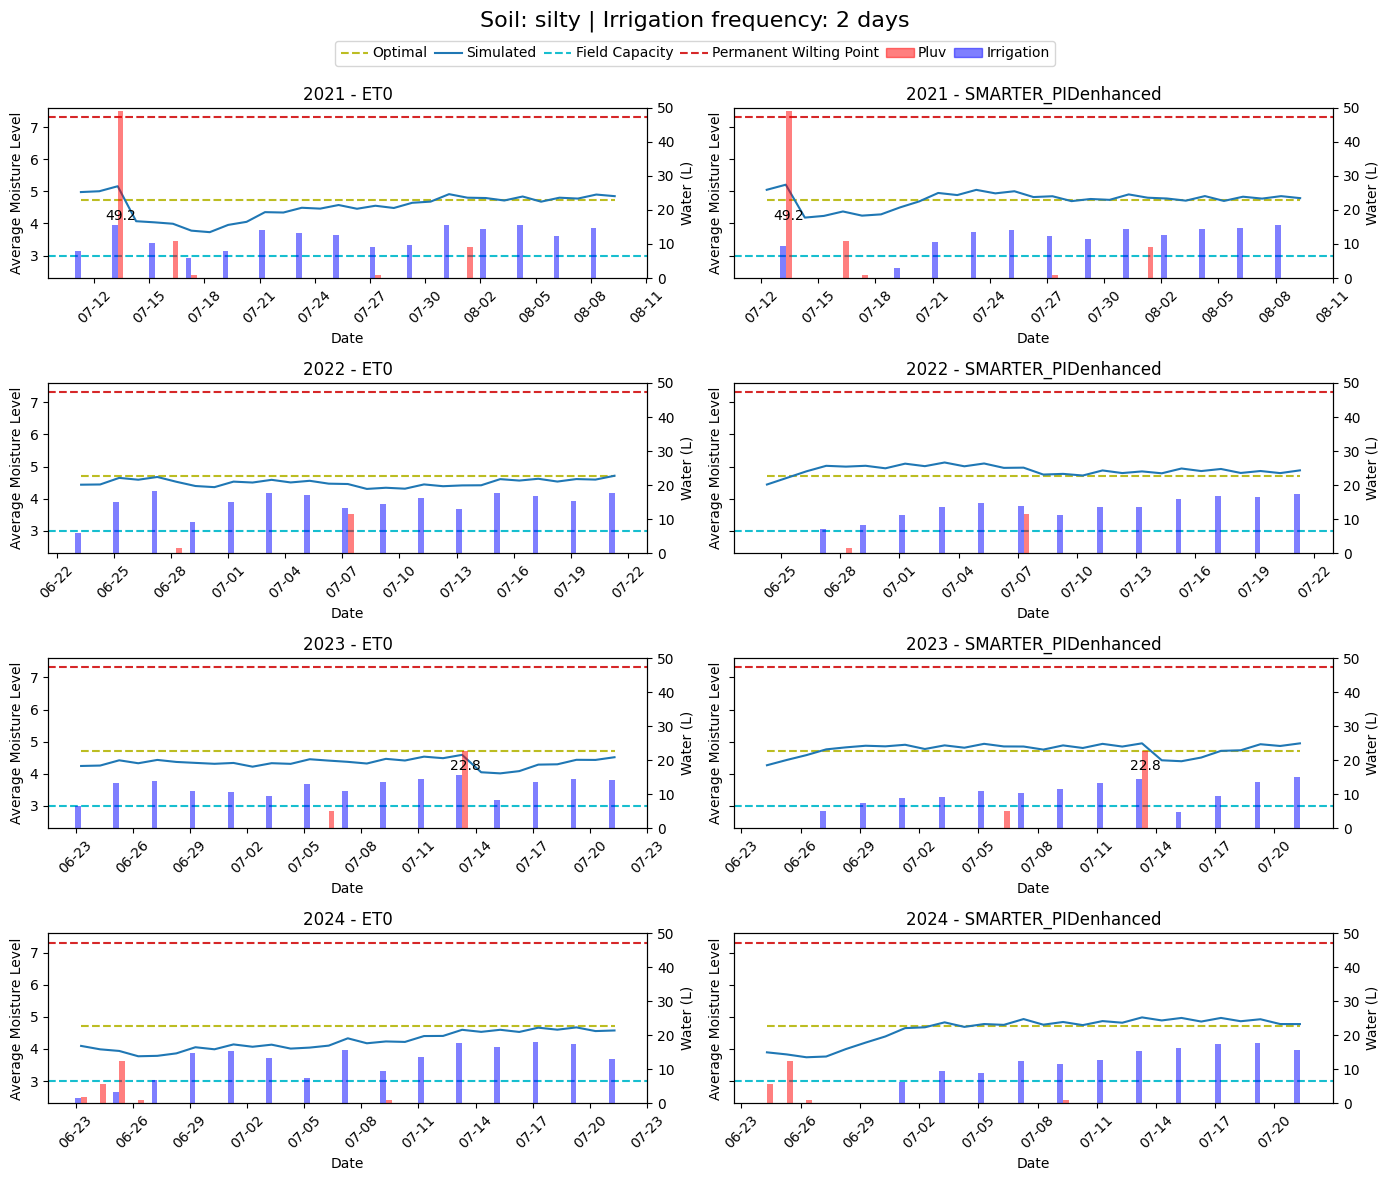

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


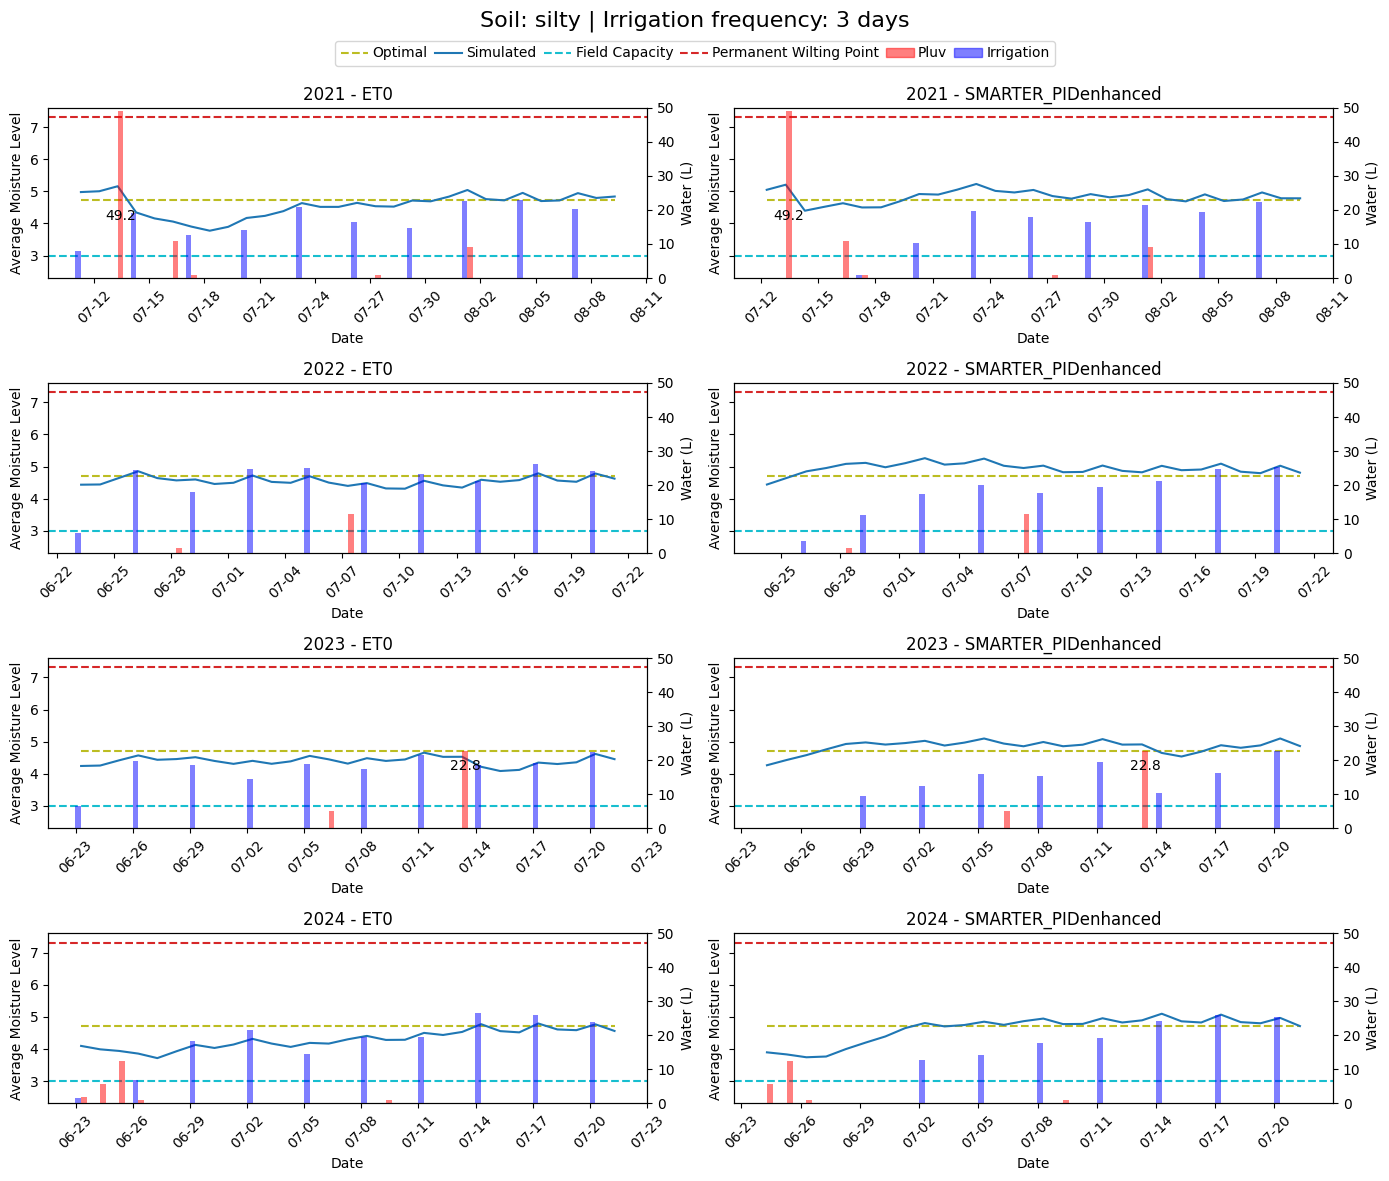

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


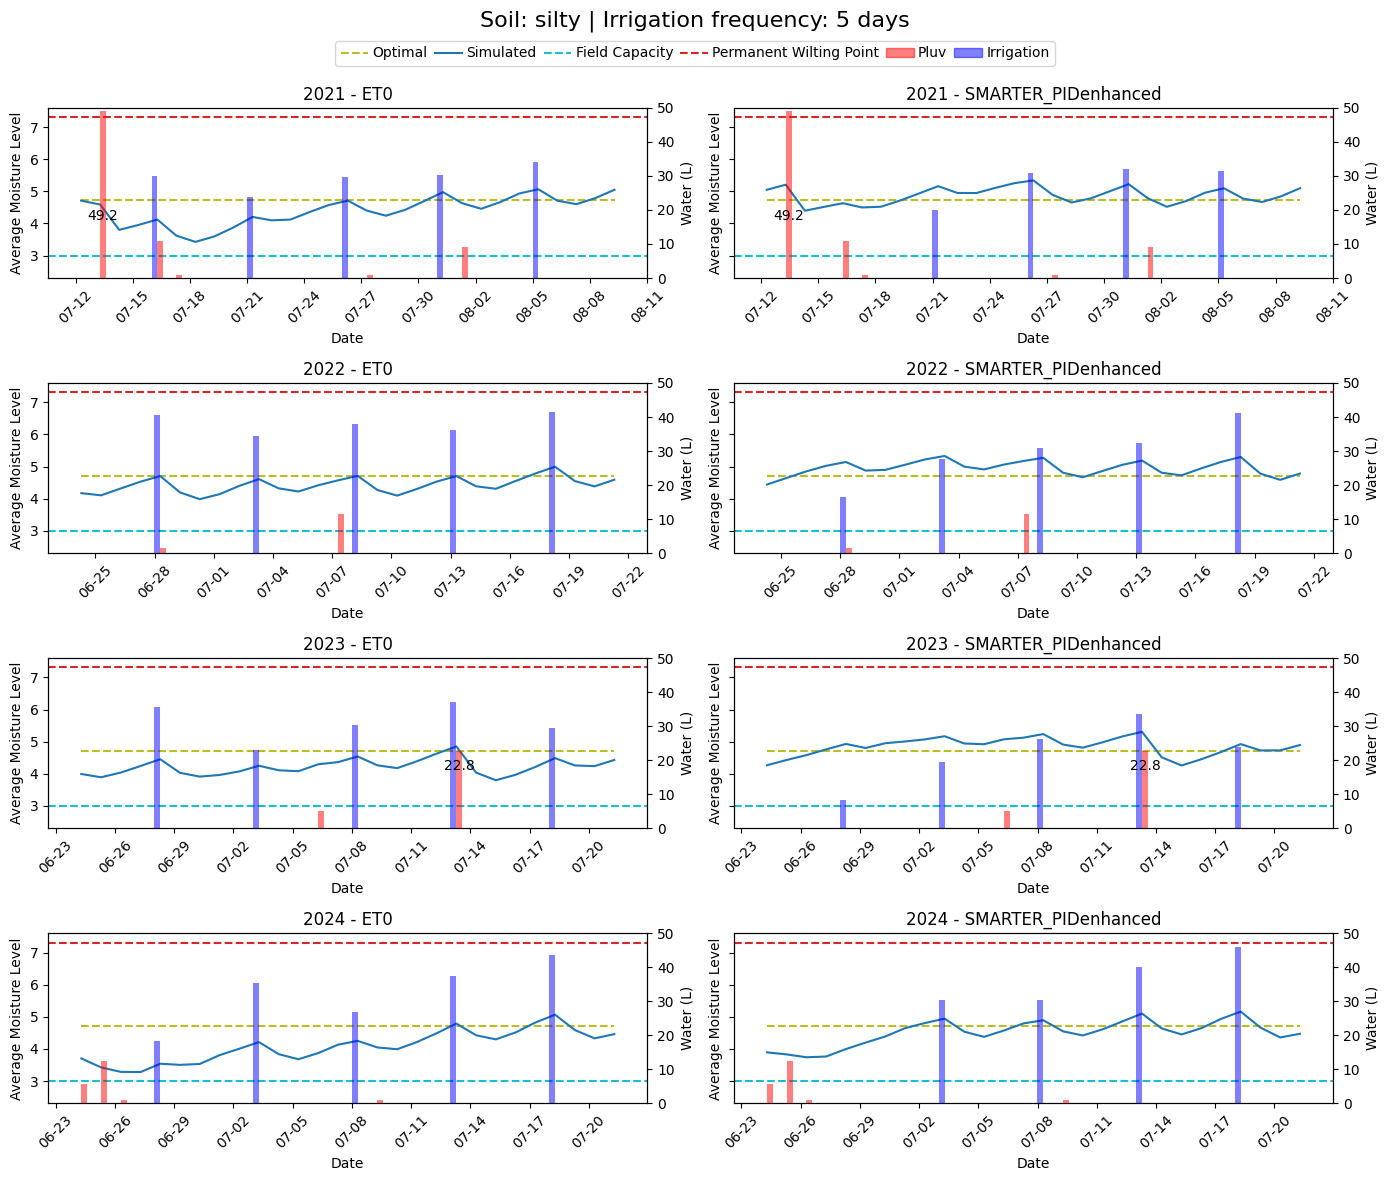

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


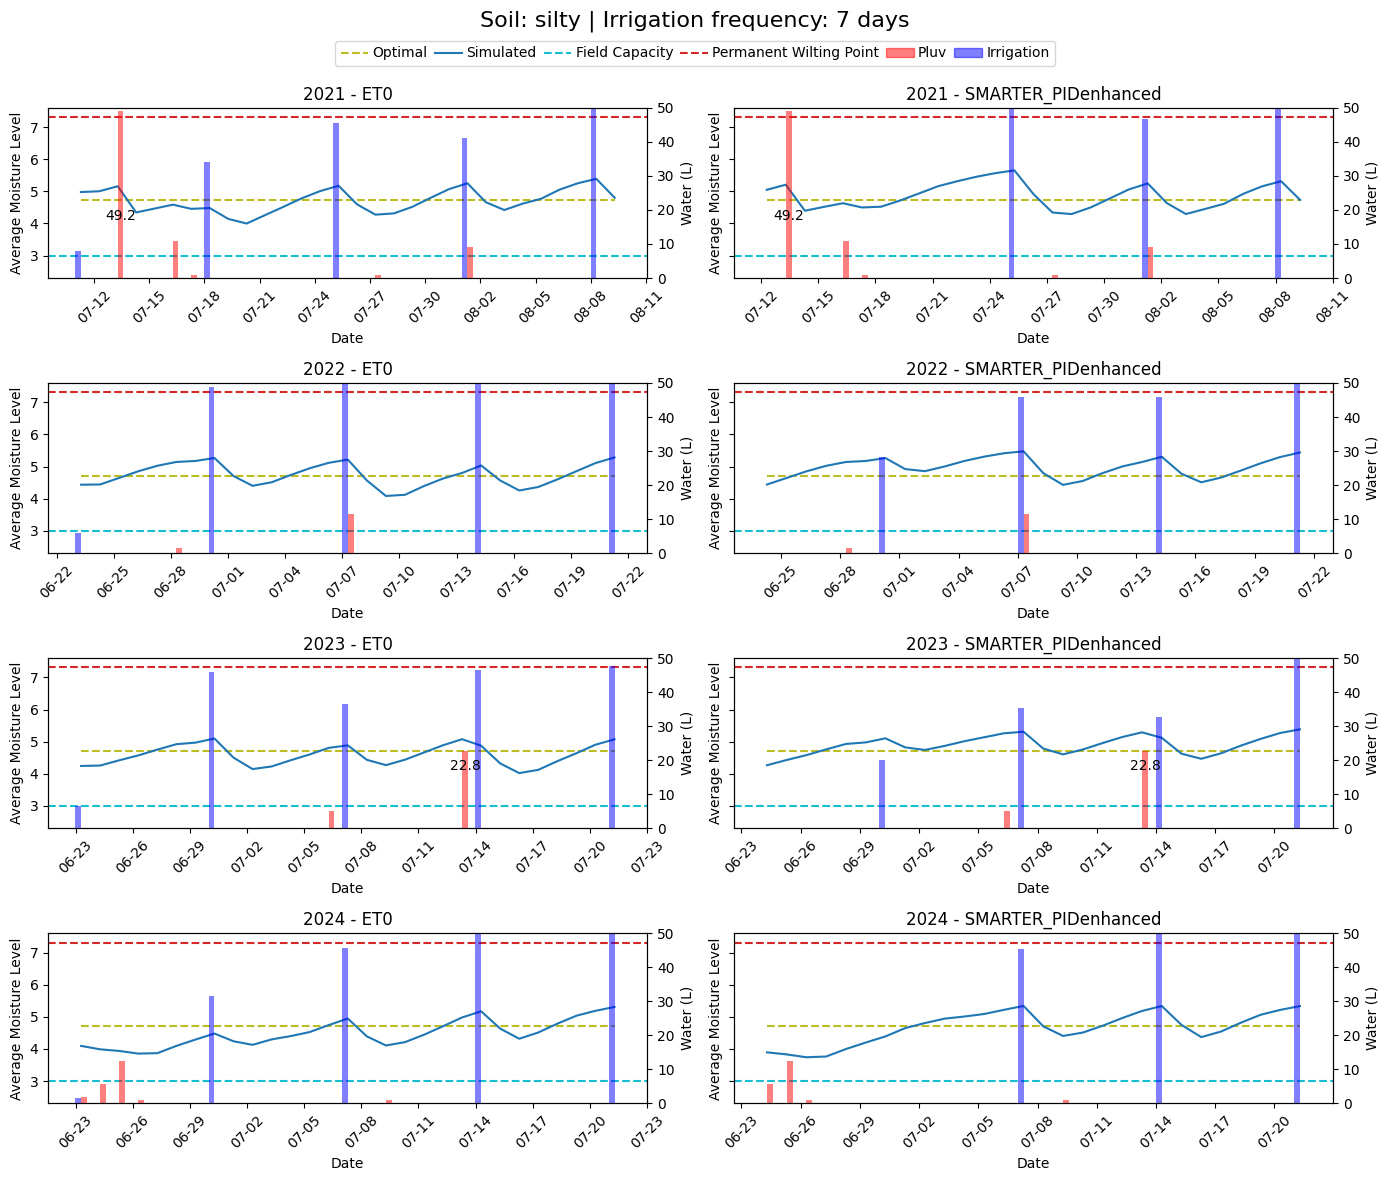

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


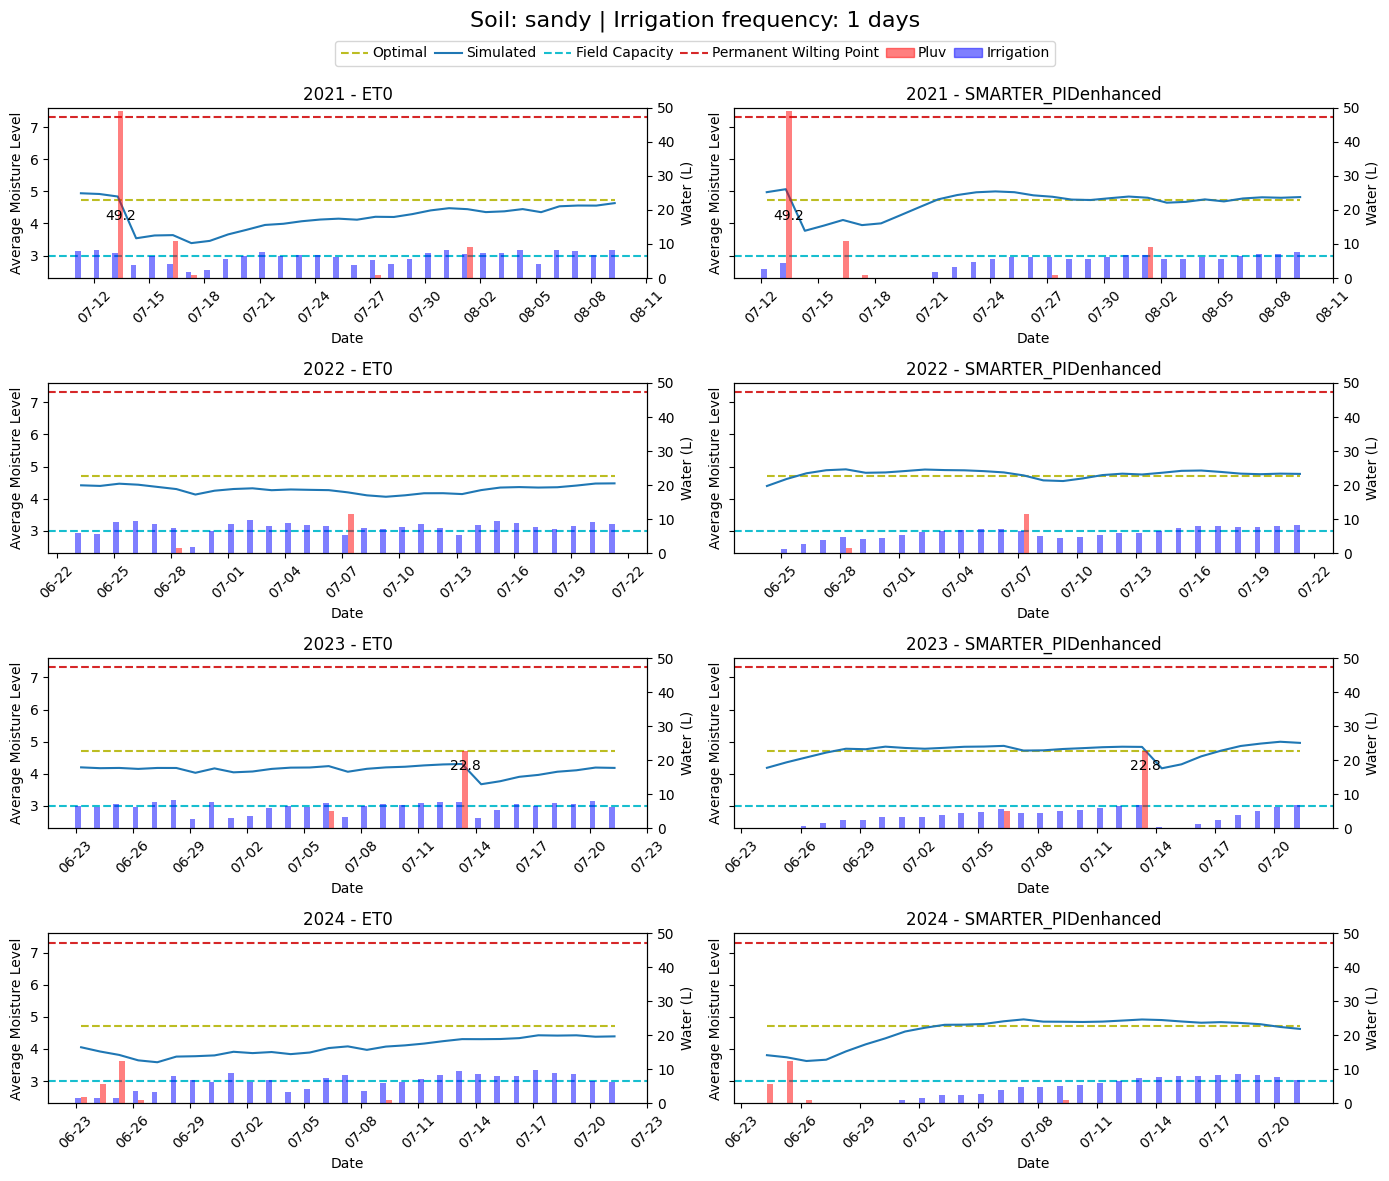

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


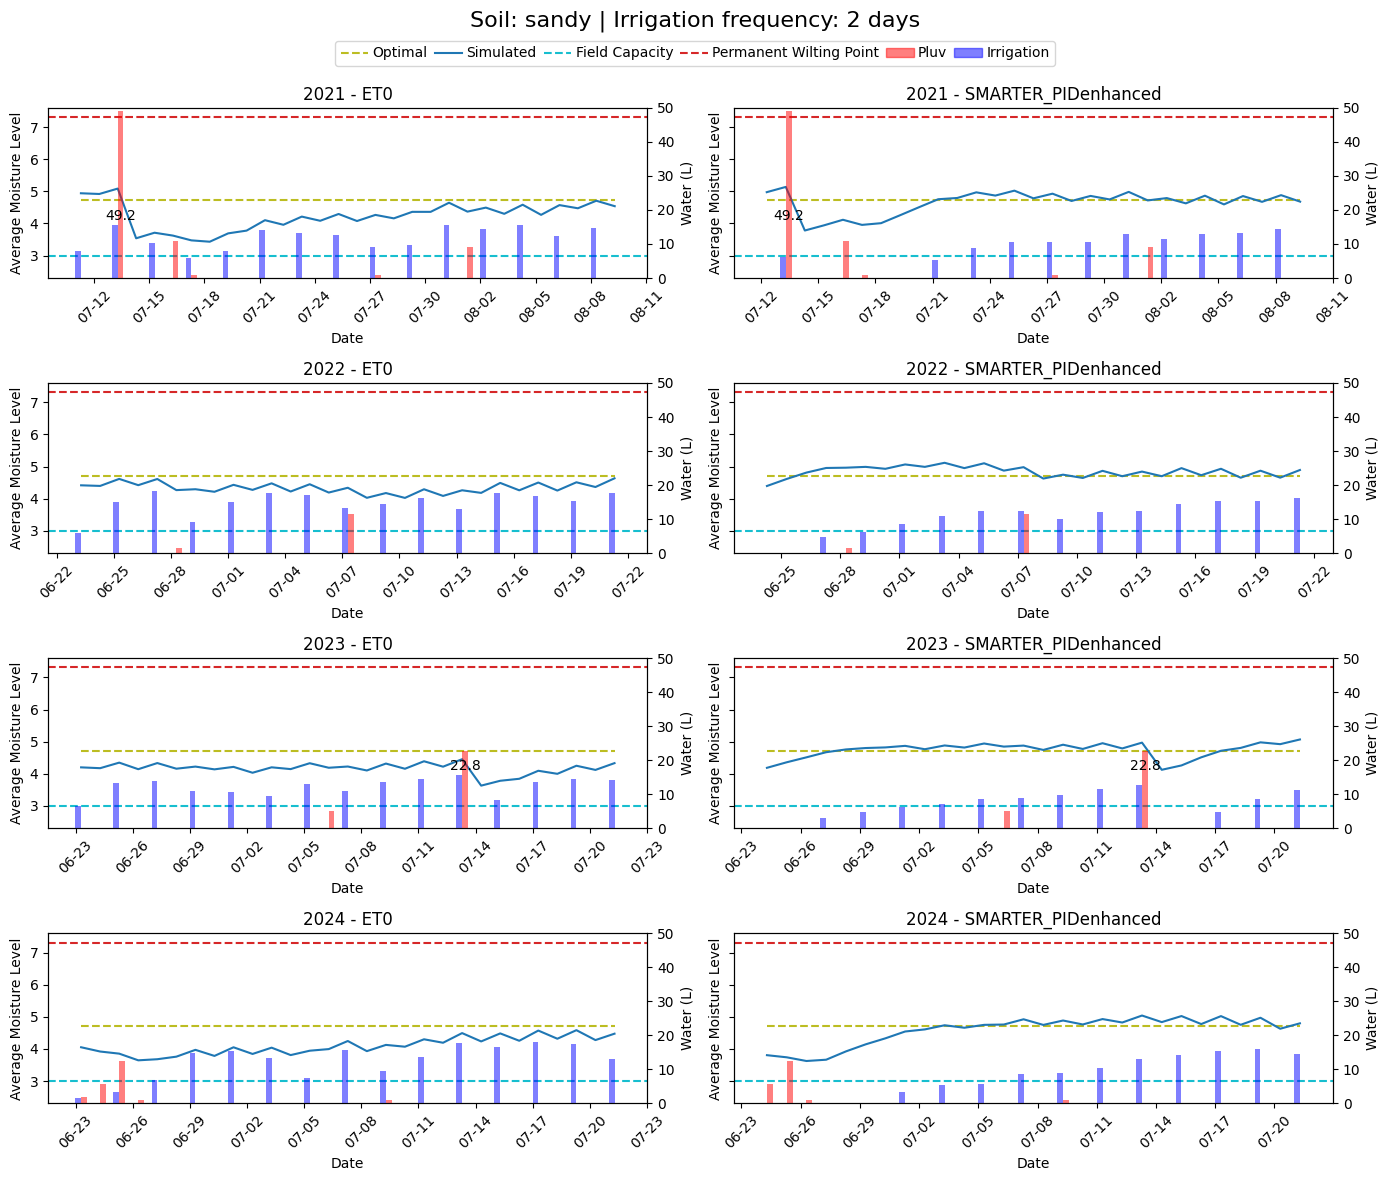

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


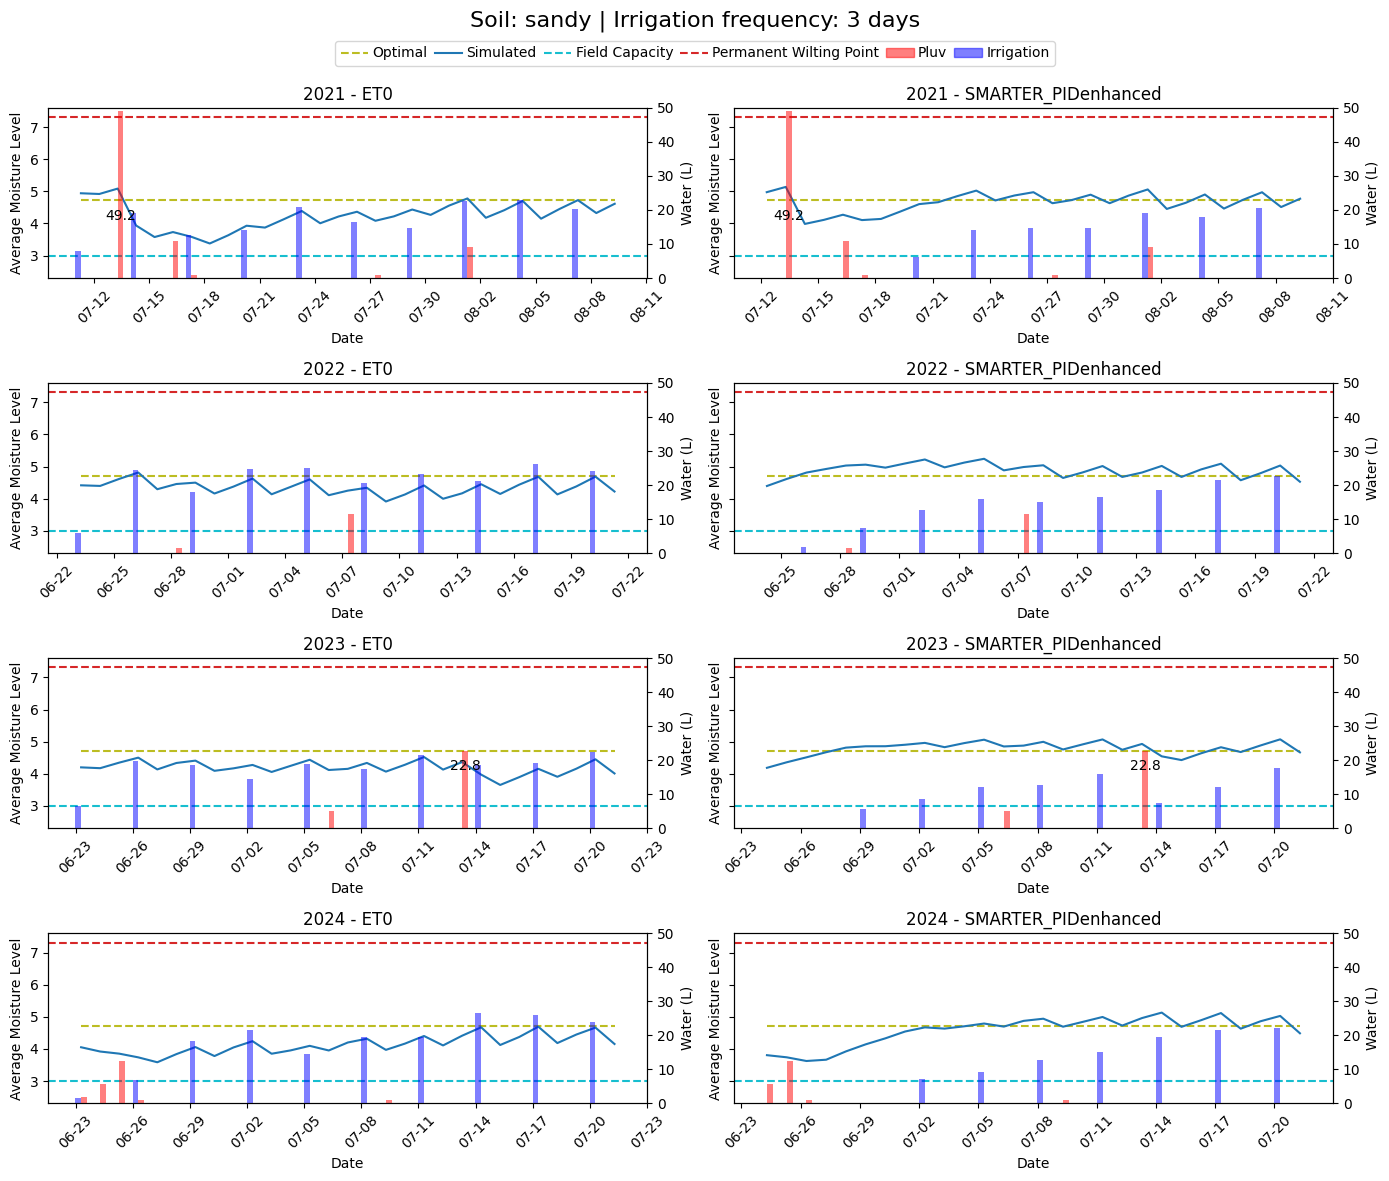

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


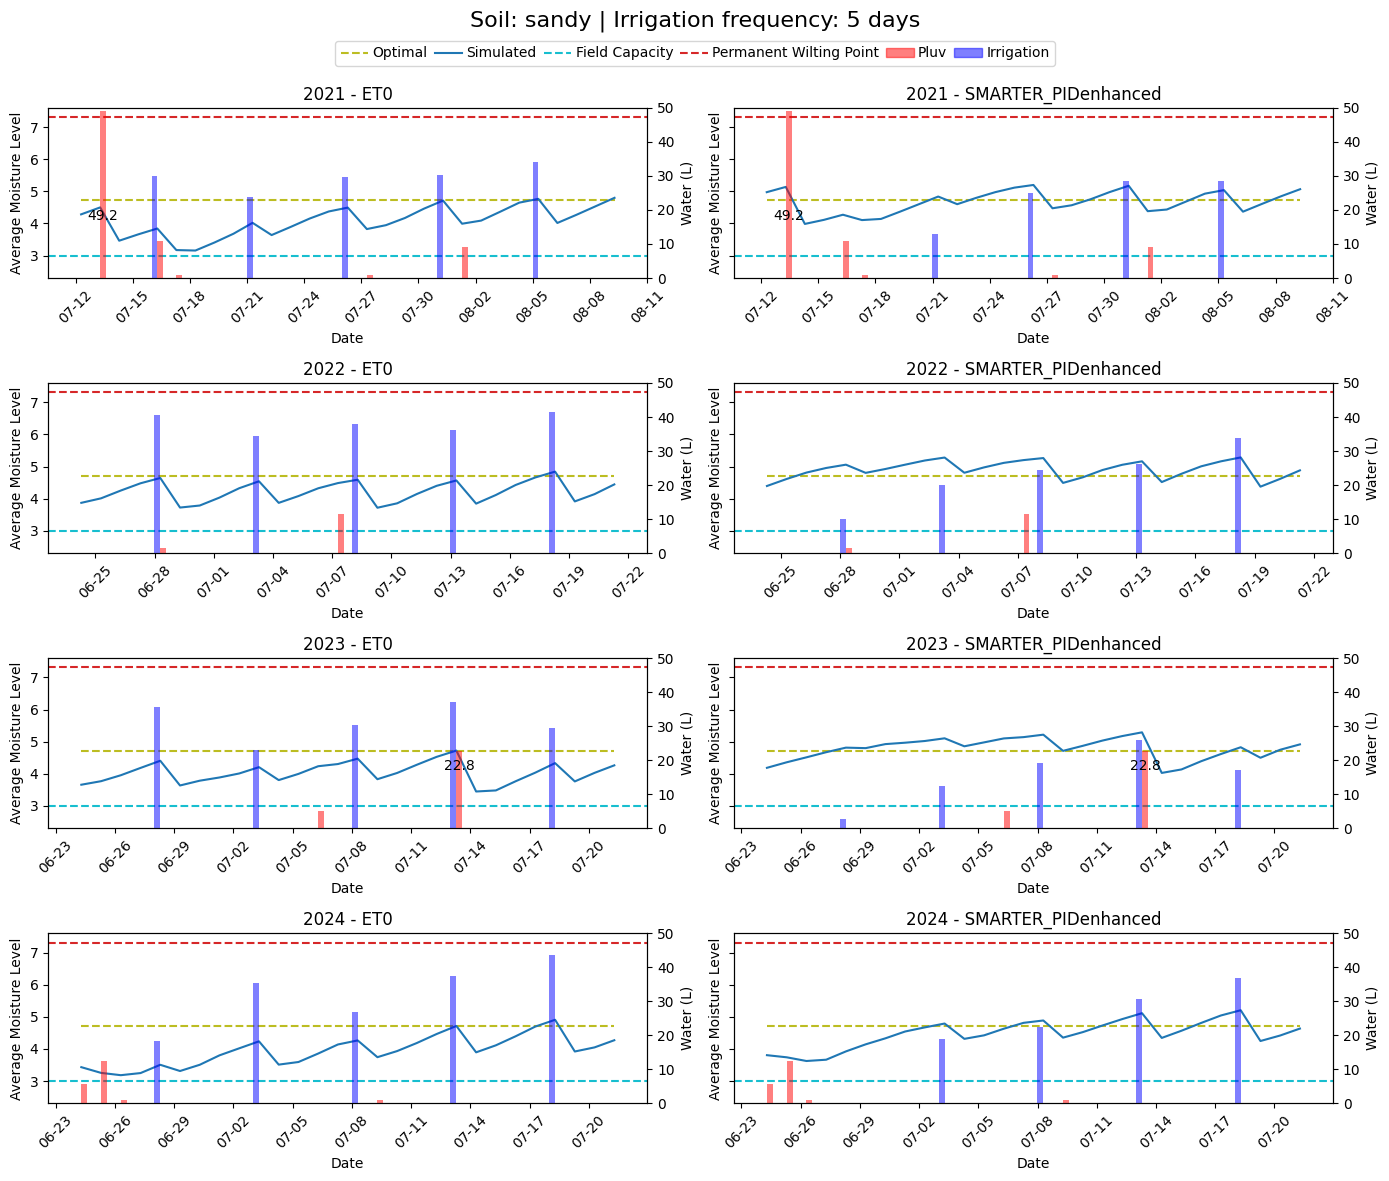

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


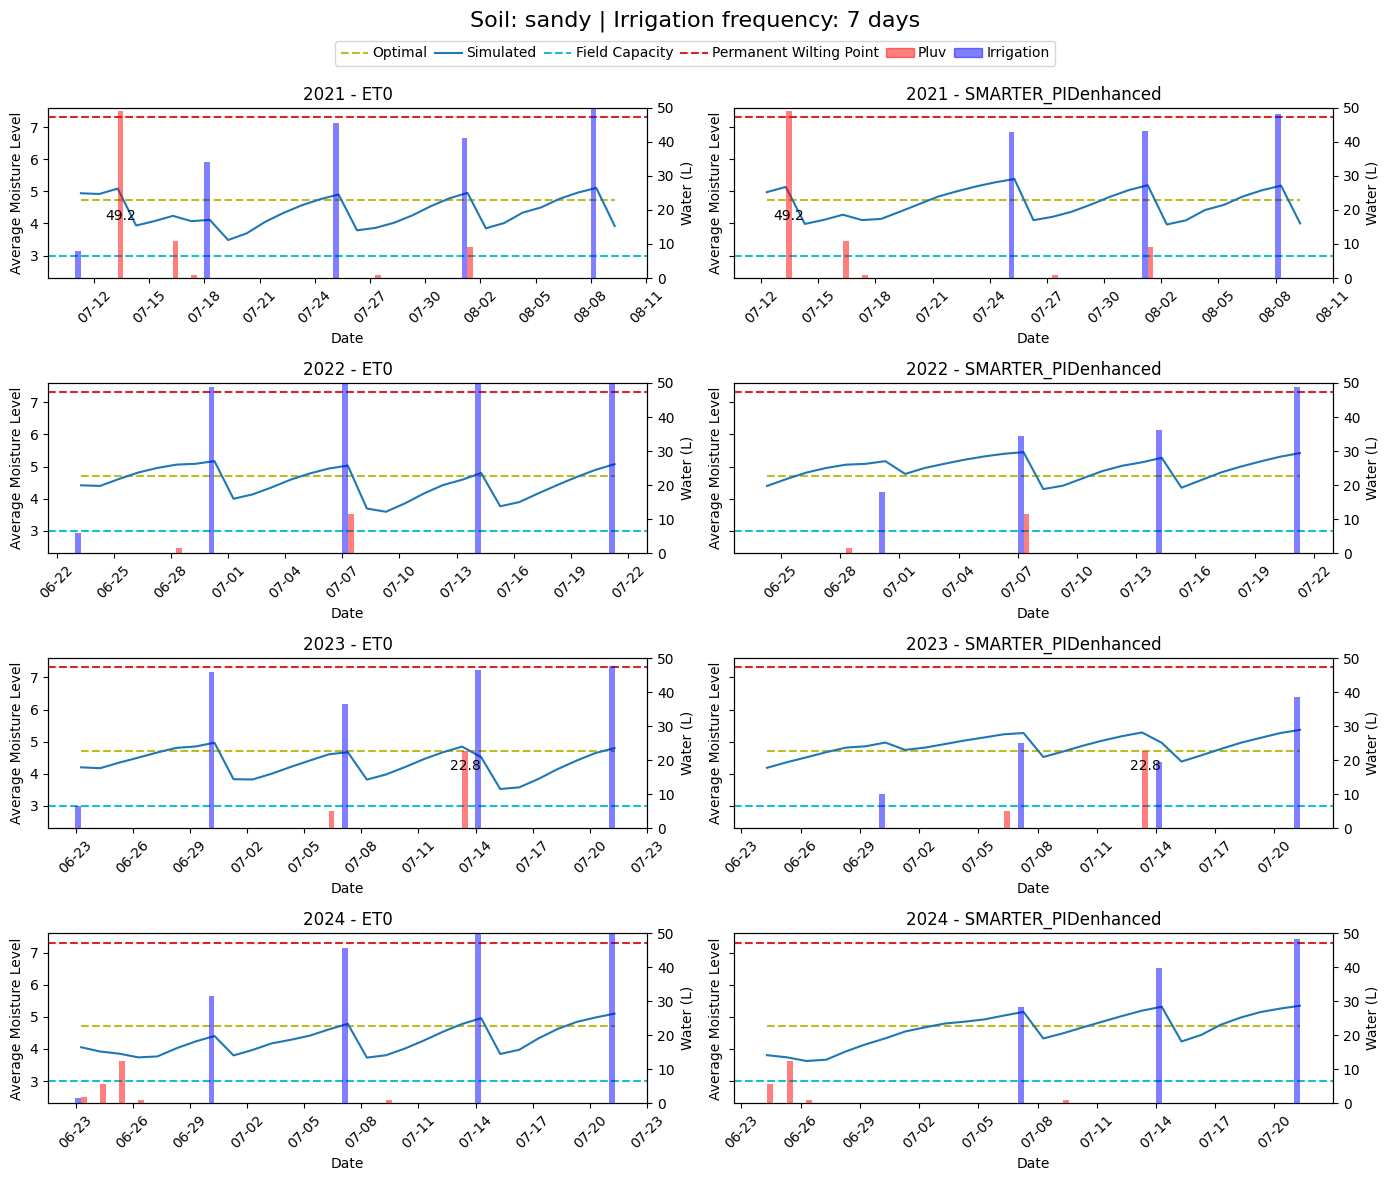

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


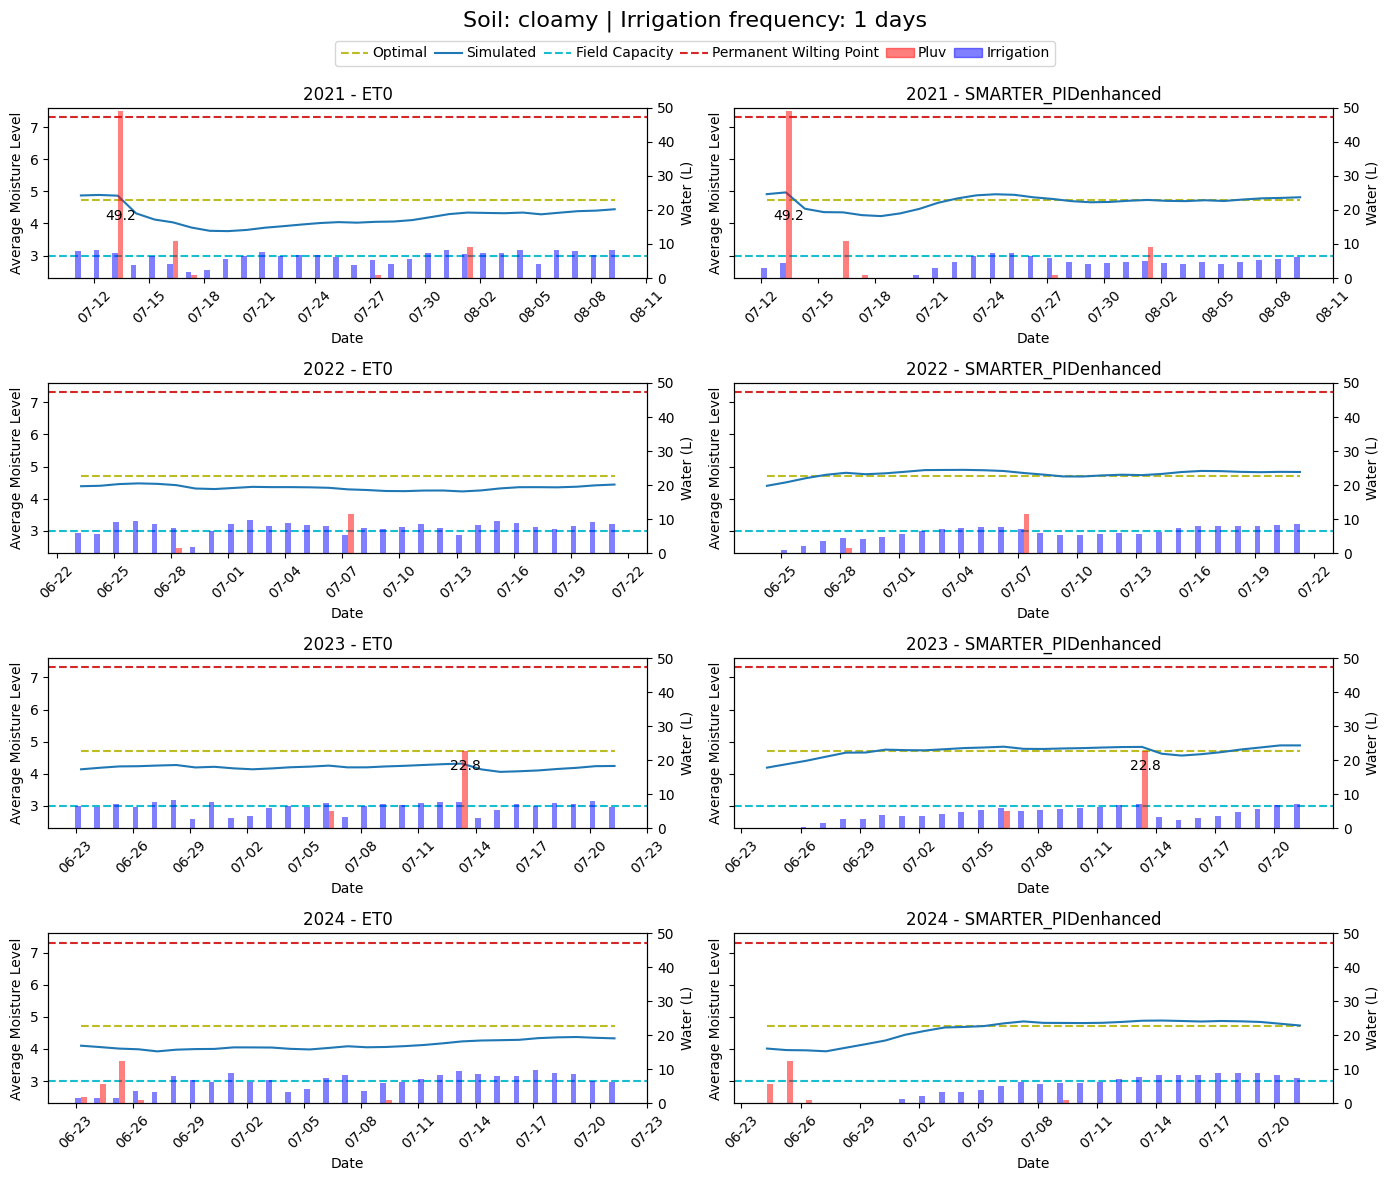

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


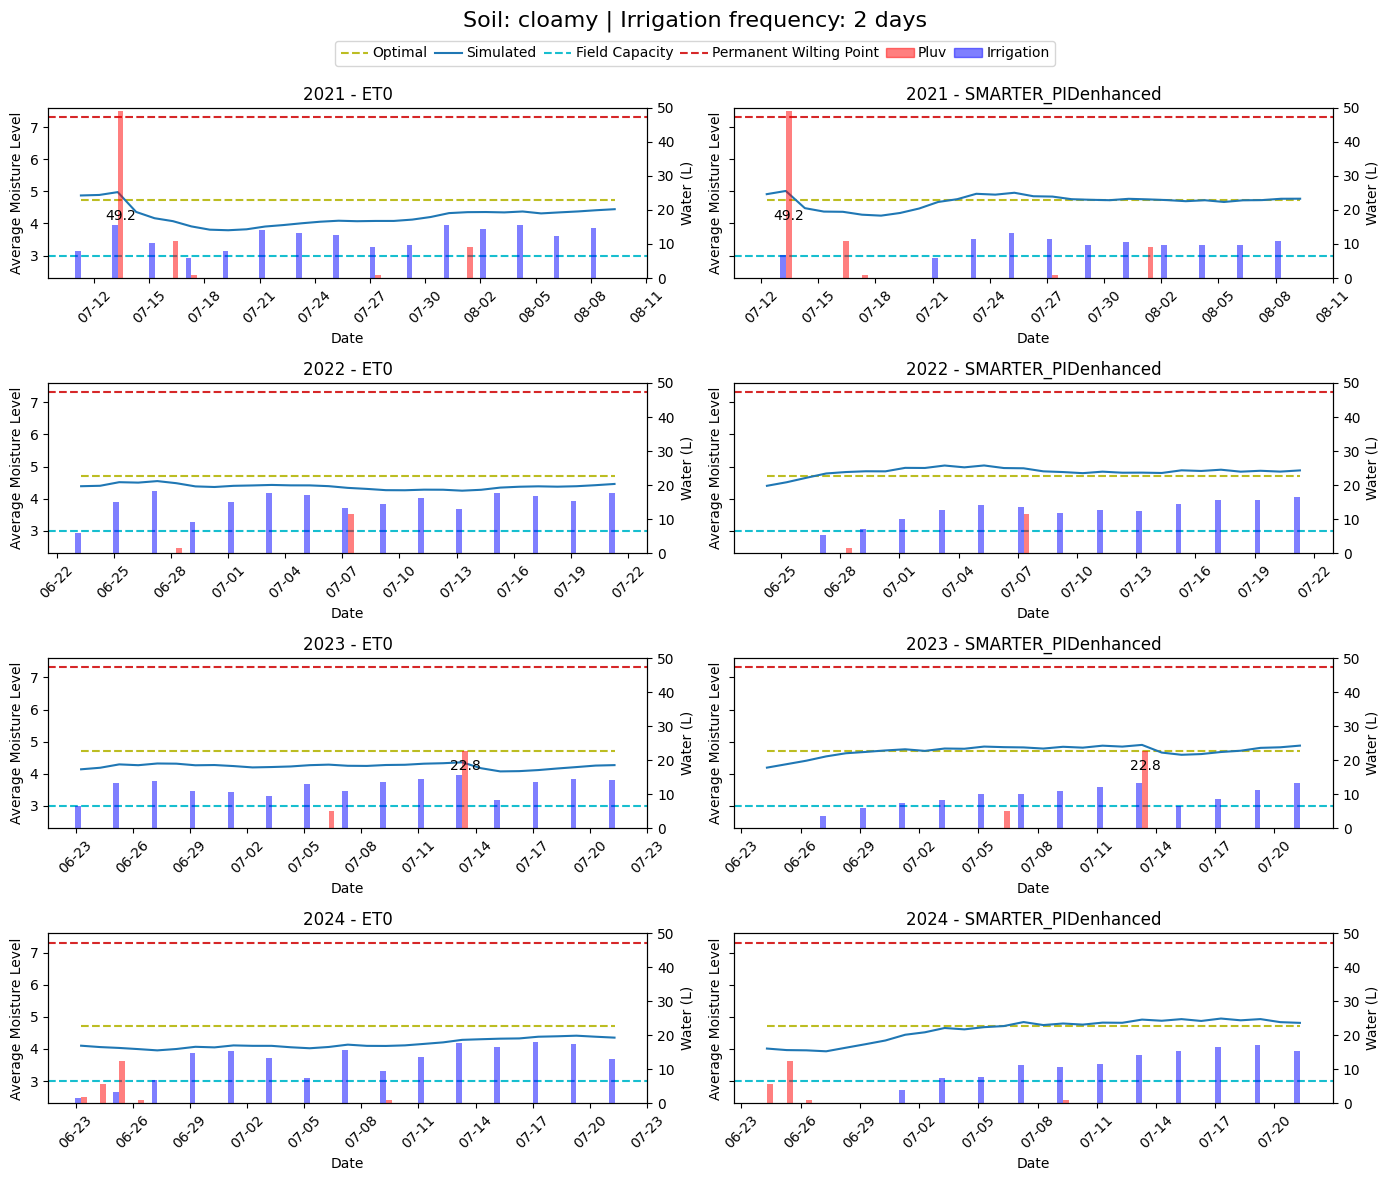

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


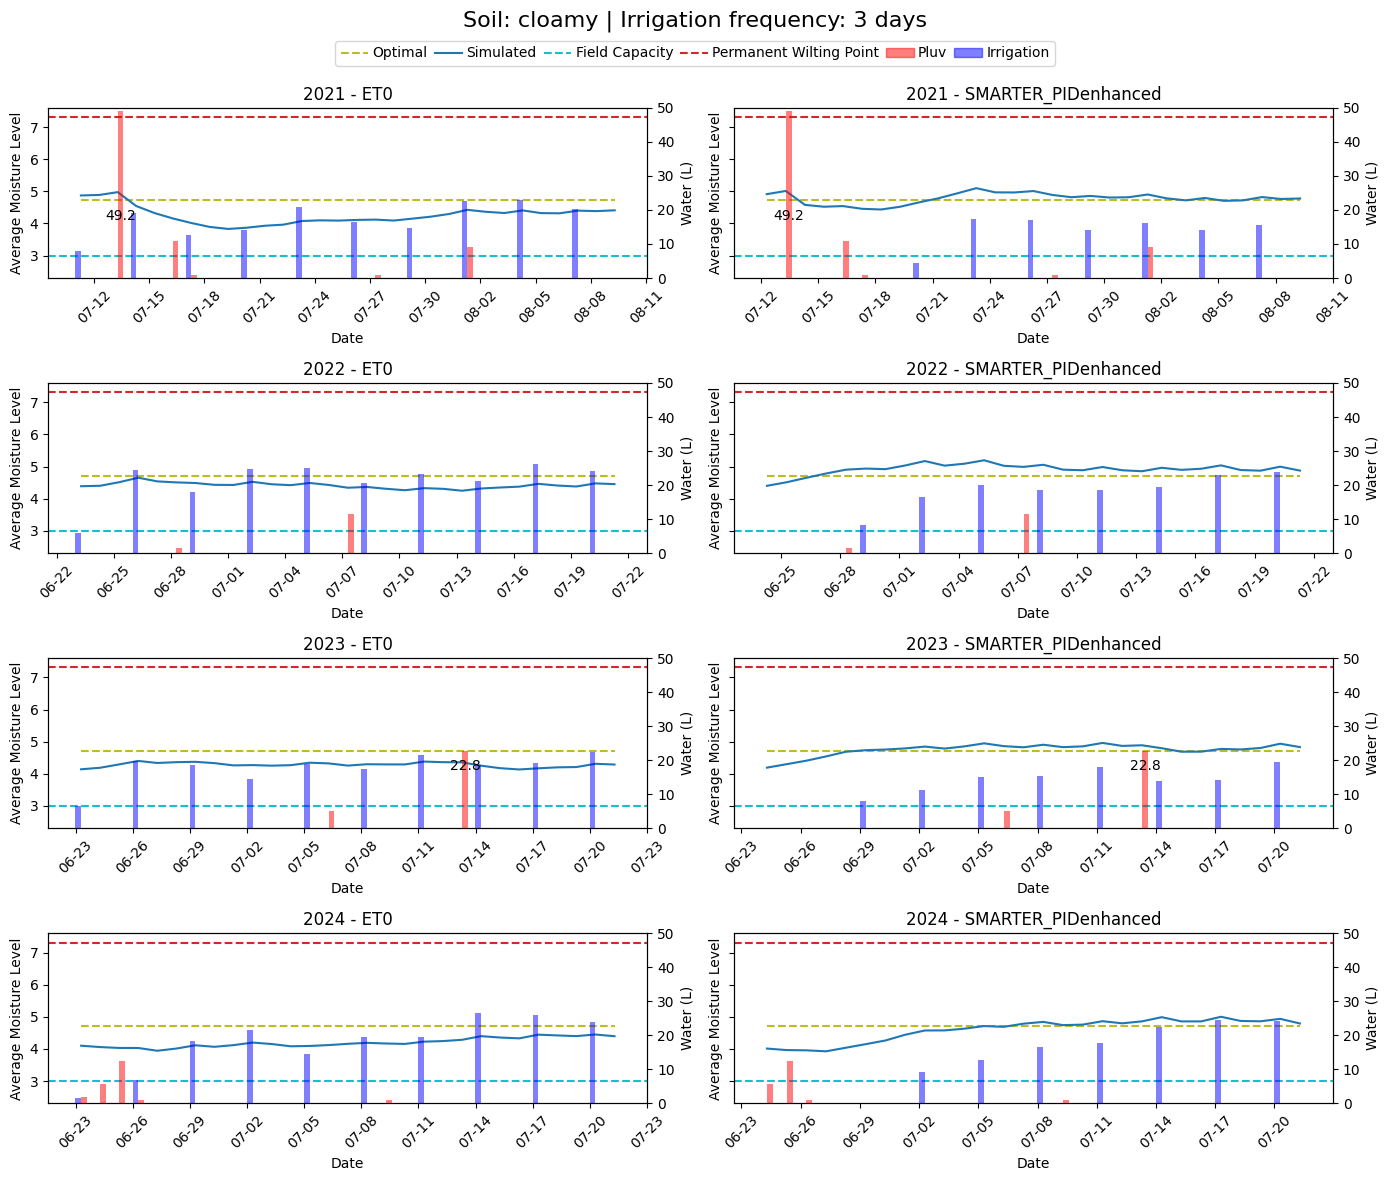

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


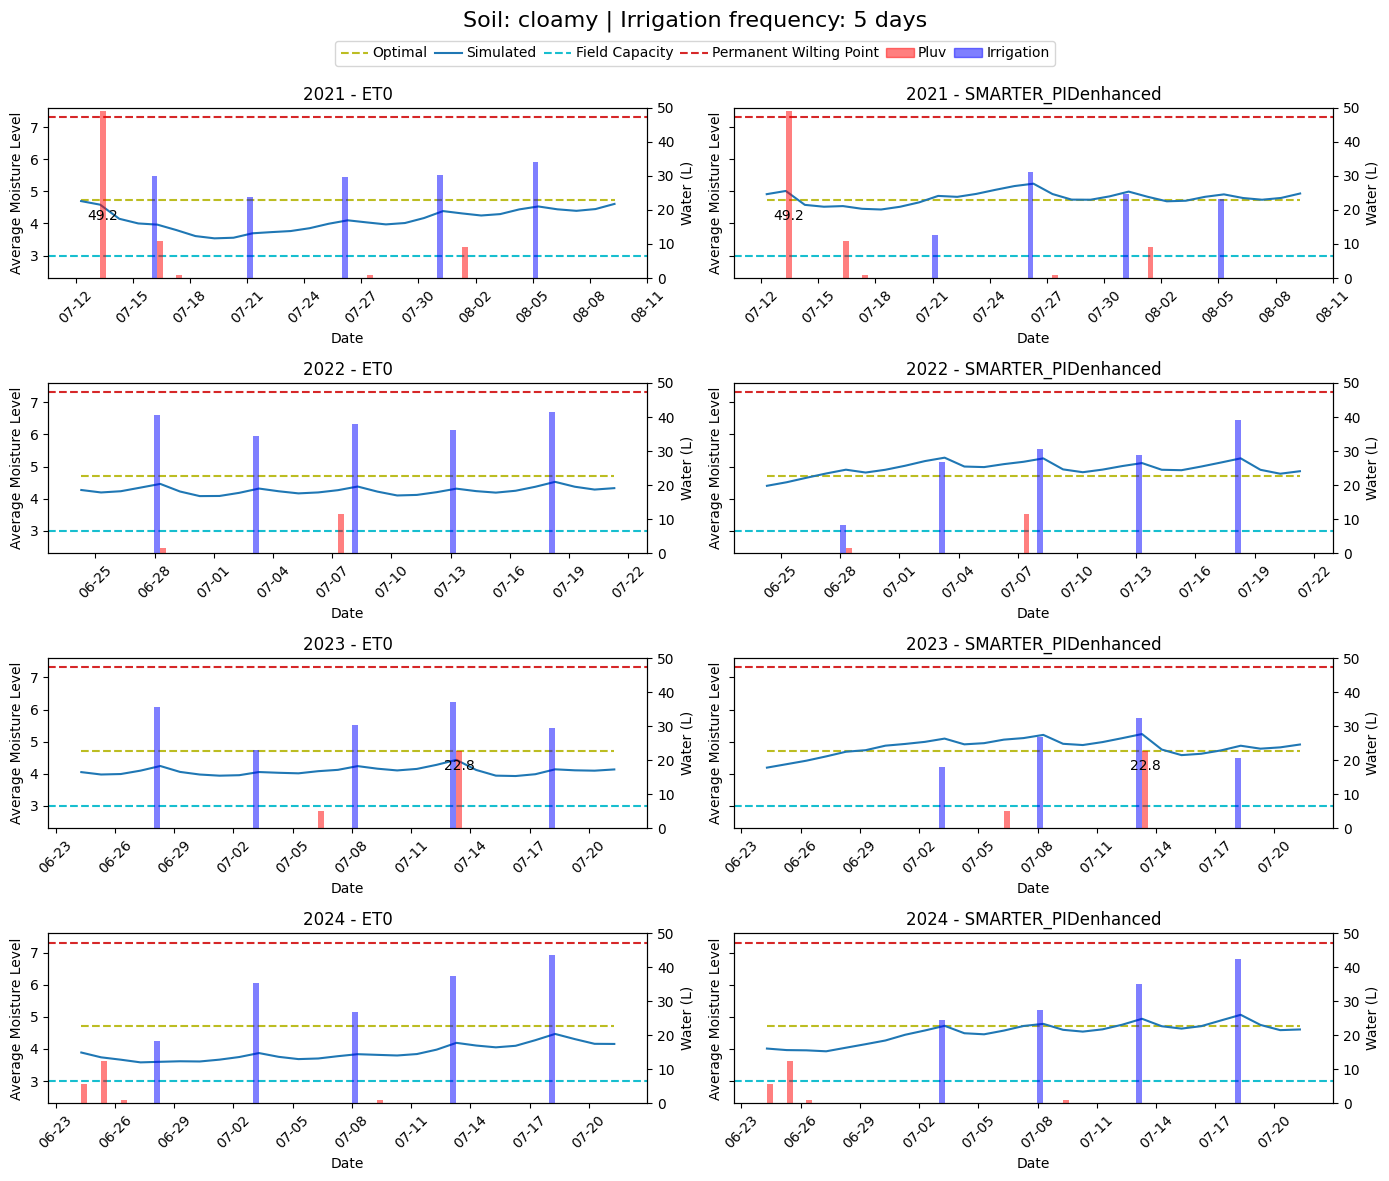

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


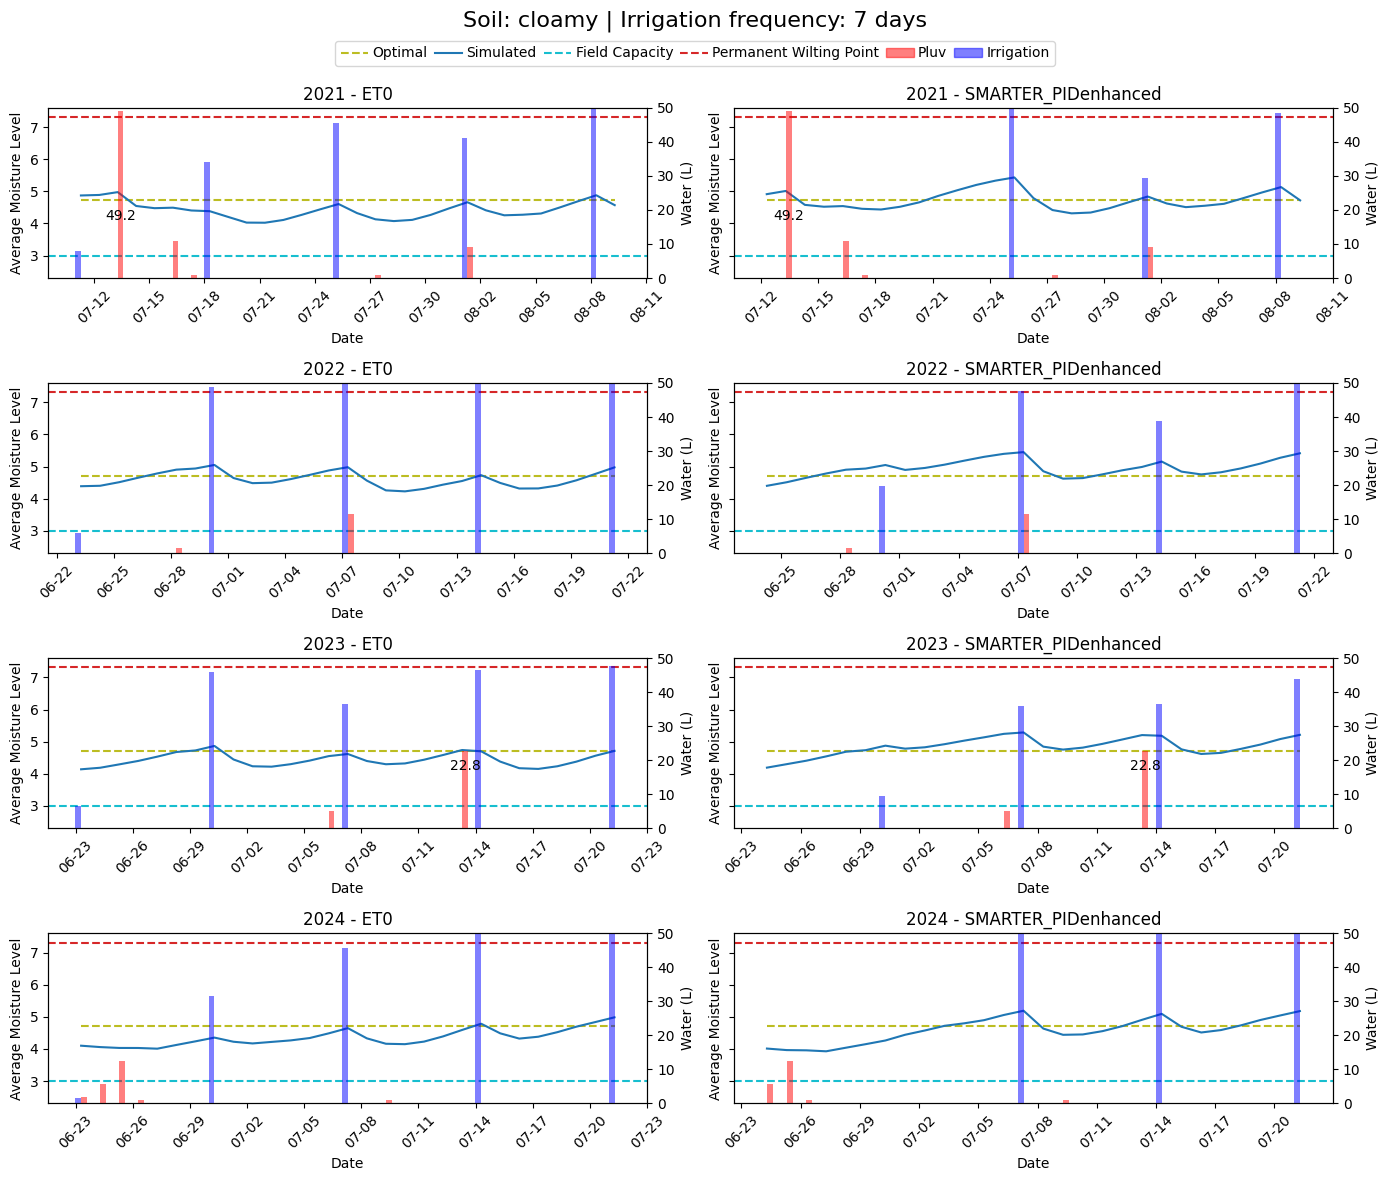

In [13]:
statistics["datetime"] = pd.to_datetime(statistics["timestamp"], unit="s")
scenarios = sorted(statistics["scenario"].unique())
strategies = sorted(statistics["irrigation_strategy"].unique())
frequencies = sorted(statistics["irrigation_frequency"].unique())

def plot_opt_obs_general(sub_df, ax, legend_elements):
    df_plot = sub_df.copy().drop_duplicates(["timestamp", "scenario"])
    df_plot.sort_values(by="timestamp", inplace=True)
    
    # Secondo asse Y per delta e daily_pluv
    ax2 = ax.twinx()
    bar_width, offset = 0.3, 3.6
    ax2.bar(df_plot["datetime"] - pd.Timedelta(hours=offset), df_plot["delta"], bar_width,
            label='Irrigation', color='blue', alpha=0.5)
    ax2.bar(df_plot["datetime"] + pd.Timedelta(hours=offset), df_plot["daily_pluv"], bar_width,
            label='Pluv', color='red', alpha=0.5)
    df_plot[df_plot["daily_pluv"] > 20].apply(
        lambda d: ax2.text(d["datetime"] + pd.Timedelta(hours=offset), 17, d["daily_pluv"],
                            color='black', ha='center'), axis=1)
    ax2.set_ylabel('Water (L)')
    ax2.set_ylim([0, 50])
    
    # Linee sul primo asse Y
    line1, = ax.plot(df_plot["datetime"], df_plot["opt_avg"], label='Optimal', linestyle='--', color='C8')
    line2, = ax.plot(df_plot["datetime"], df_plot["obs_avg"], label='Simulated', color='C0')
    
    # Linee orizzontali FC e PWP
    line_fc = ax.axhline(y=log(20), label='Field Capacity', color='C9', linestyle='--')
    line_pwp = ax.axhline(y=log(1500), label='Permanent Wilting Point', color='C3', linestyle='--')
    
    ax.set_xlabel('Date')
    ax.set_ylabel('Average Moisture Level')
    ax.set_title(f"{df_plot['scenario'].iloc[0]} - {df_plot['irrigation_strategy'].iloc[0]}")
    ax.set_ylim([log(10), log(2000)])
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.xaxis.set_major_locator(MaxNLocator(15, integer=True, prune='both'))

    # Aggiorna legenda
    for line in [line1, line2, line_fc, line_pwp]:
        if line.get_label() not in [elem.get_label() for elem in legend_elements]:
            legend_elements.append(line)
    for label, color in [('Pluv', 'red'), ('Irrigation', 'blue')]:
        if label not in [elem.get_label() for elem in legend_elements]:
            legend_elements.append(mpatches.Patch(color=color, alpha=0.5, label=label))
    ax.tick_params(axis='x', rotation=45)
    return legend_elements

for soil in statistics["soil_texture"].unique():
    soil_df = statistics[statistics["soil_texture"] == soil]

    for freq in frequencies:
        sub_df = soil_df[soil_df["irrigation_frequency"] == freq]

        fig, axes = plt.subplots(len(scenarios), len(strategies), figsize=(14, 3 * len(scenarios)),
                                 sharex=False, sharey=True)
        fig.suptitle(f"Soil: {soil} | Irrigation frequency: {freq} days", fontsize=16)
        axes = axes if len(scenarios) > 1 else [axes]

        legend_elements = []
        for i, scenario in enumerate(scenarios):
            for j, strat in enumerate(strategies):
                ax = axes[i, j] if len(scenarios) > 1 else axes[j]
                data_plot = sub_df[(sub_df["scenario"] == scenario) & (sub_df["irrigation_strategy"] == strat)]

                if data_plot.empty:
                    ax.set_visible(False)
                    continue

                legend_elements = plot_opt_obs_general(data_plot, ax, legend_elements)

        # Legenda comune
        fig.legend(legend_elements, [elem.get_label() for elem in legend_elements],
                   loc='upper center', bbox_to_anchor=(0.5, 0.96), ncol=6, columnspacing=0.5, labelspacing=0,
                   handletextpad=0.3)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()